# Transfer Learning with Tensorflow : Fine Tuning

In [1]:
# Check if we're using a GPU
!nvidia-smi

Sat Mar  7 13:40:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-03-07 13:40:59--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-07 13:40:59 (118 MB/s) - ‘helper_functions.py’ saved [10246/10246]



## Get some data

link : https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

In [3]:
# Import helper functions
from helper_functions import create_tensorboard_callback , plot_loss_curves , unzip_data , walk_through_dir

In [4]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

unzip_data("10_food_classes_10_percent.zip")

--2026-03-07 13:41:08--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.130.207, 74.125.68.207, 172.217.194.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.130.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  23.2MB/s    in 8.3s    

2026-03-07 13:41:16 (19.3 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [5]:
# Check out how many images and subdirectories are in our dataset
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent

In [6]:
# Create training and test directories paths
train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

In [7]:
import tensorflow as tf

IMG_SIZE = (244, 244)
BATCH_DATA = 32

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical",
                                                                            batch_size=BATCH_DATA)

test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                image_size=IMG_SIZE,
                                                                label_mode="categorical",
                                                                batch_size=BATCH_DATA)


Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [8]:
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [9]:
# Check class names of our dataset
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [10]:
# See an example of a batch
for images , labels in train_data_10_percent.take(1) :
    print(images , labels)

tf.Tensor(
[[[[7.68706665e+01 4.98706665e+01 5.68706665e+01]
   [7.55382309e+01 4.95382271e+01 5.85382271e+01]
   [7.77786942e+01 5.17786865e+01 6.27786865e+01]
   ...
   [8.09181137e+01 1.01721706e+01 4.41721725e+01]
   [7.48416443e+01 6.36069775e+00 3.79180450e+01]
   [7.36147232e+01 8.61472607e+00 3.89298363e+01]]

  [[7.61611786e+01 4.91611824e+01 5.44398689e+01]
   [7.88359299e+01 5.19752769e+01 5.92539635e+01]
   [8.02131195e+01 5.42131119e+01 6.34918022e+01]
   ...
   [7.99291992e+01 9.18325520e+00 4.31832542e+01]
   [7.74756088e+01 8.53285980e+00 4.20822296e+01]
   [7.59562454e+01 1.09562454e+01 4.37759476e+01]]

  [[7.69672089e+01 4.90983620e+01 5.36639366e+01]
   [8.20108185e+01 5.51639328e+01 6.05901642e+01]
   [8.33032761e+01 5.74344254e+01 6.30000000e+01]
   ...
   [7.90611496e+01 7.99115229e+00 4.35818100e+01]
   [8.08607407e+01 1.17648916e+01 4.80000000e+01]
   [7.90000000e+01 1.23861113e+01 4.87877769e+01]]

  ...

  [[2.12754074e+02 2.43754074e+02 2.47885239e+02]
   [2

## Model 0 : Building a transfer learning model using the Keras Functional API

The sequential API is straight-forward , it runs our layers in sequential order .

In [11]:
# Create the base model with tf.keras.applications

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False
)

# Freez the base model (so the underlying pre-trained patterns aren't updated during training)
base_model.trainable = False

# Create the inputs into our model
inputs = tf.keras.layers.Input(shape=(244, 244, 3) , name="input_layer")

# Normalize the inputs
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1/255.)(inputs)

# Pass the inputs to the base model
x = base_model(inputs)

print(f"Shape after passing inputs through base model : {x.shape}")

# Average pool the outputs of the base model (aggregate the most importantt features)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"Shape after global average pooling 2D : {x.shape}")

# Create the output activation layer
outputs = tf.keras.layers.Dense(10 , activation="softmax" , name="output_layer")(x)

# Combine the inputs with the outputs into a model
model_0 = tf.keras.Model(inputs , outputs)

# Compile the model
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_10_percent = model_0.fit(train_data_10_percent,
                                  epochs=5,
                                  steps_per_epoch=len(train_data_10_percent),
                                  validation_data=test_data,
                                  validation_steps=len(test_data),
                                  callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                  experiment_name="10_percent_data")])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape after passing inputs through base model : (None, 7, 7, 1280)
Shape after global average pooling 2D : (None, 1280)
Saving TensorBoard log files to: transfer_learning/10_percent_data/20260307-134129
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2845 - loss: 2.1416 - val_accuracy: 0.7168 - val_loss: 1.3362
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - accuracy: 0.7396 - loss: 1.2020 - val_accuracy: 0.8092 - val_loss: 0.8858
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.8086 - loss: 0.8185 - val_accuracy: 0.8332 - val_loss: 0.7115
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.8708 - loss: 0.6513 - val_accuracy: 0.8440 - val_loss: 0.6177
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.8546 - loss: 0.5683 - val_accuracy: 0.8528 - val_loss: 0.5634


In [12]:
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

In [13]:
# Evaluate on the full test dataset
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8408 - loss: 0.5749


[0.5634381175041199, 0.8528000116348267]

In [14]:
# Check the layers in our base model
for layers in base_model.layers :
    print(layers.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand

In [15]:
# How about to get a summary of the base model layers ?

base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# Whole model summary
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

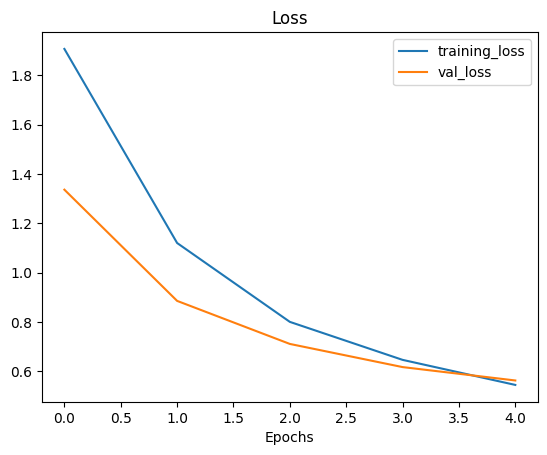

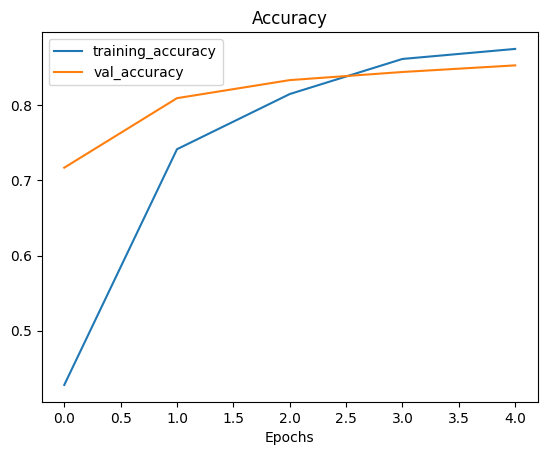

In [17]:
# Check out our model's training curves
plot_loss_curves(history_10_percent)

## Getting a feature vector from a trained model

Let's demonstrate the Global Average Pooling 2D layer ...

We have a tensor after our model goes through `base_model` of shape (None , 7 , 7 , 1280)...

But then when it passes through GlobalAveragePooling 2D  , it turns into (None , 1280) .

Let's use a similar shaped tensor of (1,4,4,3) and then pass it to GlobalAveragePooling2D .


In [18]:
# Define the input shape
input_shape = (1 , 4, 4, 3)

# Create a random tensor
tf.random.set_seed(42)
input_tensor = tf.random.normal(input_shape)
print(f"Random input tensor : \n {input_tensor}\n")

Random input tensor : 
 [[[[ 0.3274685  -0.8426258   0.3194337 ]
   [-1.4075519  -2.3880599  -1.0392479 ]
   [-0.5573232   0.539707    1.6994323 ]
   [ 0.28893656 -1.5066116  -0.2645474 ]]

  [[-0.59722406 -1.9171132  -0.62044144]
   [ 0.8504023  -0.40604794 -3.0258412 ]
   [ 0.9058464   0.29855987 -0.22561555]
   [-0.7616443  -1.8917141  -0.93847126]]

  [[ 0.77852213 -0.47338894  0.97772694]
   [ 0.24694404  0.20573746 -0.52562326]
   [ 0.32410017  0.02545409 -0.10638496]
   [-0.63694745  1.1603122   0.2507359 ]]

  [[-0.41728503  0.4012578  -1.4145443 ]
   [-0.5931857  -1.6617213   0.33567193]
   [ 0.10815628  0.23479679 -0.56668764]
   [-0.35819843  0.88698614  0.52744764]]]]



In [19]:
# Pass the random tensor throught a global average pooling 2D layer
global_average_pooled_tensor = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)

In [20]:
print(f"2D global average pooled random tensor : \n {global_average_pooled_tensor}")

2D global average pooled random tensor : 
 [[-0.09368646 -0.45840448 -0.2885598 ]]


In [21]:
# Check the shape of the different tensors
print(f"Shape of input tensor : {input_tensor.shape}")
print(f"Shape of Global Average Pooled 2D tensor : {global_average_pooled_tensor.shape}")

Shape of input tensor : (1, 4, 4, 3)
Shape of Global Average Pooled 2D tensor : (1, 3)


In [22]:
# Let's replicate the GlobalAveragePool2D layer
tf.reduce_mean(input_tensor , axis=[1,2])

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[-0.09368646, -0.45840448, -0.2885598 ]], dtype=float32)>

## Running a series of transfer learning experiments

We've seen the incredible results transfer learning can get with only 10% of the training data , but how does it go with 1% of the training data ... how about we set up a bunch of experiments to find out :

1. `model_1` - use feature extraction transfer learning with 1% of the training data with data augumentation
2. `model_2` - use feature extraction transfer learning with 10% of the training with data augumentation
3. `model_3` - use fine-tuning transfer learning on 10% of the training data with data augumentation
4. `model_4` - use fine-tuning transfer learning on 100% of the training data with data augumentation

🔑 **Note** : throught all experiments the same test dataset will be used to evaluate our model .. this ensures consistency across evaluation metrics .

In [23]:
# Download and unzip data - FOOD101 preprocessed
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip

unzip_data("10_food_classes_1_percent.zip")

--2026-03-07 13:43:18--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.118.207, 74.125.24.207, 74.125.200.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.118.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M  21.5MB/s    in 7.6s    

2026-03-07 13:43:26 (16.8 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [24]:
# Create training and test dirs
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir = "10_food_classes_1_percent/test"

In [25]:
# How many images are we working with
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_wings'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/hamburger'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/grilled_salmon'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_curry'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/steak'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ice_cream'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/fried_rice'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/pizza'.
There a

In [26]:
# Setup data loaders
IMG_SIZE = (244,244)
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_1_percent,
                                                                           label_mode="categorical",
                                                                           image_size=IMG_SIZE,
                                                                           batch_size=32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                batch_size=32)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


## Adding data augumentation right into the model

To add data augumentation right into our models , we can use the layers inside :

* `tf.keras.layers.experimental.preprocessing()`

Data augumentation : https://www.tensorflow.org/guide/keras/preprocessing_layers

* Preprocessing of images (augumenting them) happens on the GPU (much faster) rather than the CPU
* Image data augumentation only happens during training , so we can still export our whole model and use it elsewhere

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Create data augumentation stage with horizontal flipping , rotations , zooms etc..
data_augumentation = keras.Sequential([
    layers.Resizing(244,244),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
    #layers.Rescale(1./255) # Keep from models like ResNet50V2 but EfficientNet's having rescaling built-in
] , name = "data_augumentation")

## Visualize our data augumentation layer (and see what happens to our data)

(np.float64(-0.5), np.float64(243.5), np.float64(243.5), np.float64(-0.5))

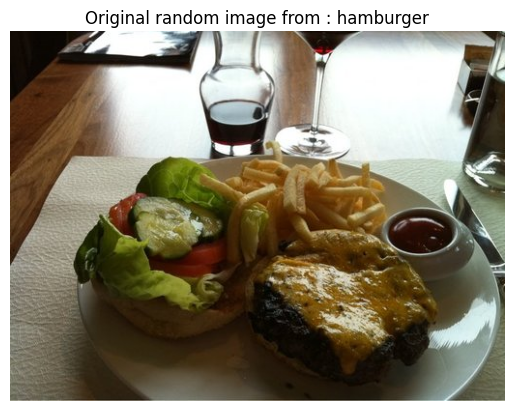

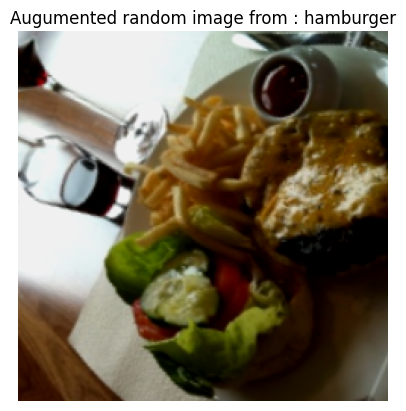

In [28]:
# View a random image and compare it to its augumented version
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

target_class = random.choice(train_data_1_percent.class_names)
target_dir = "10_food_classes_1_percent/train/" + target_class
random_image = random.choice(os.listdir(target_dir))
random_image_path = target_dir + "/" + random_image

# Read and plot in the random image
img = mpimg.imread(random_image_path)
#print(img)
plt.imshow(img)
plt.title(f"Original random image from : {target_class}")
plt.axis(False)

# Now let's plot our augumented random image
augumented_img = data_augumentation(img , training=True)
plt.figure()
plt.imshow(tf.squeeze(augumented_img)/255.)
plt.title(f"Augumented random image from : {target_class}")
plt.axis(False)

## Model 1 : Feature extraction transfer learning on 1% of the data with data augumentation

In [29]:
data_aug = keras.Sequential([
    layers.Resizing(244,244),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
    #layers.Rescale(1./255) # Keep from models like ResNet50V2 but EfficientNet's having rescaling built-in
] , name = "data_augumentation_2")

In [30]:

# Setup input shape and base model , freezing the base model layers
input_shape = (244,244,3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape , name="input_layer")

# Add in data augumentation Sequential model as a layer
x = data_aug(inputs)

# Give base_model the inputs (after augumentation) and don't train it
x = base_model(x , training=False)

# Pool output features of the base model
x = layers.GlobalAveragePooling2D()(x)

# Put a dense layer on as the output
outputs = layers.Dense(10 , activation="softmax" , name="output_layer")(x)

# Make a model using the inputs and outputs
model_1 = keras.Model(inputs , outputs)

# Compile the model
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1_percent = model_1.fit(train_data_1_percent,
                                epochs=5,
                                steps_per_epoch=len(train_data_1_percent),
                                validation_data=test_data,
                                validation_steps=int(0.25 * len(test_data)),
                                # Track model training logs
                                callbacks=[create_tensorboard_callback(dir_name="transfer_learning" , experiment_name="1_percent_data_aug")])

Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260307-134333
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.0410 - loss: 2.4541 - val_accuracy: 0.1612 - val_loss: 2.2782
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 869ms/step - accuracy: 0.1944 - loss: 2.2000 - val_accuracy: 0.2697 - val_loss: 2.1293
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 869ms/step - accuracy: 0.3927 - loss: 2.0025 - val_accuracy: 0.3520 - val_loss: 2.0133
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5104 - loss: 1.8770 - val_accuracy: 0.4194 - val_loss: 1.8994
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 950ms/step - accuracy: 0.6795 - loss: 1.6467 - val_accuracy: 0.4655 - val_loss: 1.8104


In [31]:
# Check out a model summary
model_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation_2            │ (None, 244, 244, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

In [32]:
# Evaluate on the full test dataset
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.4716 - loss: 1.8065


[1.8192628622055054, 0.46480000019073486]

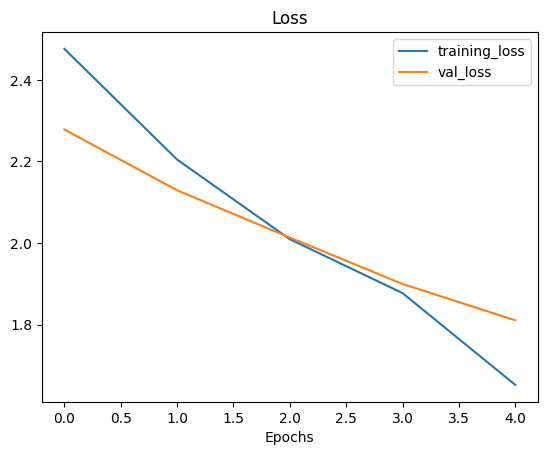

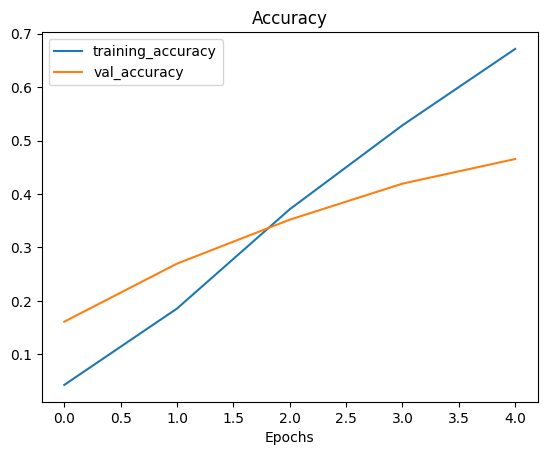

In [33]:
# How do the model with 1% of the data and data augumentation loss curves look ?
plot_loss_curves(history_1_percent)

# Model 2 : feature extraction transfer learning model with 10% of data

# Get 10% of data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

In [34]:
train_dir_10_percent = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

In [35]:
# Set data inputs
import tensorflow as tf
IMG_SIZE = (244 , 244)

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir_10_percent,
    label_mode="categorical",
    image_size=IMG_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode="categorical",
    image_size=IMG_SIZE
)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [36]:
# Create Model 2 with data augumentation built in

# Build data augumentation layer
data_ag = keras.Sequential([
    layers.Resizing(244,244),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name="data_ag")

In [37]:
# Setup input shape
input_shape = (244, 244, 3)

# Create a frozen base model (also called the backbone)
base_model_2 = tf.keras.applications.EfficientNetB0(include_top=False)
base_model_2.trainable=False

# Create inputs and outputs (including the layers in between)
inputs_2 = layers.Input(shape=input_shape , name="input_layer")

x = data_ag(inputs_2) # Augument data images

x = base_model(x , training=False) # Pass the augumented images to the base model but keep it in infderence mode , this also insures batchnorm layers don't get updated

x = layers.GlobalAveragePooling2D(name = "global_average_pooling_2D")(x)

outputs = layers.Dense(10 , activation="softmax" , name="output_layer")(x)

model_2 = tf.keras.Model(inputs_2 , outputs)

In [38]:
# Compile the model
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [39]:
model_2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_ag (Sequential)            │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_2D       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [40]:
data_ag.summary()

Model: "data_ag"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 244, 244, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 244, 244, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_2             │ (None, 244, 244, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Creating a ModelCheckpoint callback

The ModelCheckpoint callback intermediately saves our model (the full model or just the weights) during training .
Is useful so we can come and start where we left off .

In [41]:
# Set checkpoint path
checkpoint_path = "ten_percent_model_checkpoints_weights/checkpoint.weights.h5"

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True,
                                                         save_best_only=False,
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)


### Fit model 2 passing in the ModelCheckpoint callback

In [42]:
# Fit the model saving checkpoints every epoch
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                          epochs=initial_epochs,
                                          validation_data=test_data,
                                          validation_steps=int(0.25 * len(test_data)),
                                          callbacks=[create_tensorboard_callback(dir_name="transfer_learning" , experiment_name="10_percent_data_aug") , checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20260307-134411
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2171 - loss: 2.2183
Epoch 1: saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 300ms/step - accuracy: 0.2222 - loss: 2.2098 - val_accuracy: 0.7237 - val_loss: 1.3773
Epoch 2/5
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6838 - loss: 1.3848
Epoch 2: saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.6853 - loss: 1.3780 - val_accuracy: 0.8043 - val_loss: 0.9535
Epoch 3/5
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7753 - loss: 1.0158
Epoch 3: saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.7751 - loss: 1.0139 - val_accuracy: 0.8257 - val_loss: 0.7733
Epoch 4/5
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - ac

In [43]:
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8598 - loss: 0.5509


[0.5634381175041199, 0.8528000116348267]

In [44]:
results_10_percent_data_aug = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.8504 - loss: 0.6058


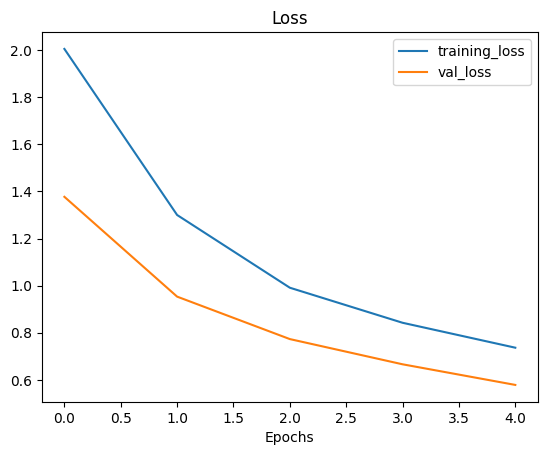

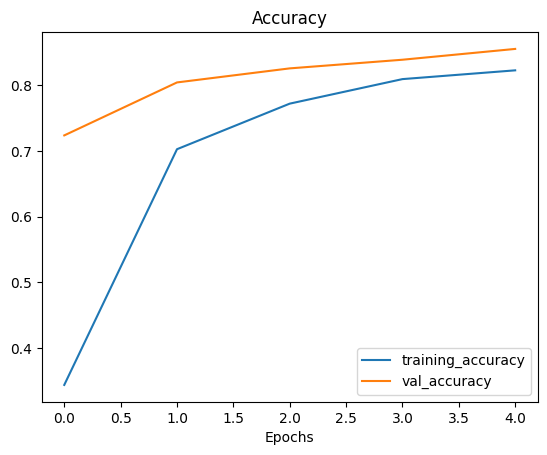

In [45]:
# Plot model loss curves
plot_loss_curves(history_10_percent_data_aug)

## Loading in checkpointed weights

Loading in checkpointed weights returns a model to a specific checkpoint .

In [46]:
# Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)

In [47]:
# Evaluate model 2 with loaded weights
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8519 - loss: 0.6007


In [48]:
# If the results from our preveously evaluated model_2 match the loaded weights everything has worked
results_10_percent_data_aug == loaded_weights_model_results

True

In [49]:
results_10_percent_data_aug

[0.6006181240081787, 0.8500000238418579]

In [50]:
loaded_weights_model_results

[0.6006181240081787, 0.8500000238418579]

## Model 3 : Fine-tuning an existing model on 10% of the data

In [51]:
# Lyers in loaded model
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=data_ag, built=True>,
 <Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling_2D, built=True>,
 <Dense name=output_layer, built=True>]

In [52]:
# Check if layers are trainable
for layer in model_2.layers:
   print(layer, layer.trainable)

<InputLayer name=input_layer, built=True> True
<Sequential name=data_ag, built=True> True
<Functional name=efficientnetb0, built=True> False
<GlobalAveragePooling2D name=global_average_pooling_2D, built=True> True
<Dense name=output_layer, built=True> True


In [53]:
for i , layers in enumerate(model_2.layers[2].layers) :
  print(i , layers.name , layers.trainable)

0 input_layer_2 False
1 rescaling_2 False
2 normalization_1 False
3 rescaling_3 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [54]:
# How many trainable variables are in our base model
print(len(model_2.layers[2].trainable_variables))

0


In [ ]:
# To begin fine-tuning , let's start by setting the last 10 layers of our base_model.trainable = True
base_model_2.trainable = True

# Freeze all layers except the last 10
for layers in base_model_2.layers[:-10] :
    layers.trainable = False

In [56]:
# Recompile (we have to recompile the models every time we make a change)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(0.0001), # When fine tuning you typically want to lower the learning rate by x10 (best practice)
                metrics=["accuracy"])


In [57]:
# Check which layer are tunnable (trainable)
for layer_number , layers in enumerate(model_2.layers[2].layers):
  print(layer_number , layer.name , layer.trainable)

0 output_layer True
1 output_layer True
2 output_layer True
3 output_layer True
4 output_layer True
5 output_layer True
6 output_layer True
7 output_layer True
8 output_layer True
9 output_layer True
10 output_layer True
11 output_layer True
12 output_layer True
13 output_layer True
14 output_layer True
15 output_layer True
16 output_layer True
17 output_layer True
18 output_layer True
19 output_layer True
20 output_layer True
21 output_layer True
22 output_layer True
23 output_layer True
24 output_layer True
25 output_layer True
26 output_layer True
27 output_layer True
28 output_layer True
29 output_layer True
30 output_layer True
31 output_layer True
32 output_layer True
33 output_layer True
34 output_layer True
35 output_layer True
36 output_layer True
37 output_layer True
38 output_layer True
39 output_layer True
40 output_layer True
41 output_layer True
42 output_layer True
43 output_layer True
44 output_layer True
45 output_layer True
46 output_layer True
47 output_layer True
48

In [58]:
# Now we've unfrozen some of the layers closer to the top , how many trainable variable are there ?
print(len(model_2.trainable_variables))

2


In [59]:
model_2.trainable_variables

[<Variable path=output_layer/kernel, shape=(1280, 10), dtype=float32, value=[[ 0.02379681 -0.06515075 -0.01169833 ... -0.02413589 -0.01224557
    0.00072656]
  [-0.04726717 -0.05080658 -0.08939268 ... -0.00401844 -0.08269181
    0.02671213]
  [ 0.05869595 -0.0543652   0.04314811 ... -0.03348818 -0.04517858
    0.01072322]
  ...
  [-0.0413716  -0.01603013 -0.0950668  ...  0.03983399  0.02879132
    0.05565393]
  [-0.03302591 -0.01046768 -0.09979379 ... -0.03509847  0.09004644
   -0.00972753]
  [-0.01330386 -0.0319819   0.00713541 ...  0.02340784 -0.0162535
   -0.02876487]]>,
 <Variable path=output_layer/bias, shape=(10,), dtype=float32, value=[ 0.00301928 -0.00169167  0.00123097 -0.01196716  0.00150844  0.00334541
   0.01503954 -0.00600551 -0.01278682  0.0007643 ]>]

In [60]:
# Fine tune for another 5 epochs
fine_tune_epochs = initial_epochs + 5

# Refit the model (same sa model_2 except with more trainable layers)
history_fine_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                               epochs=fine_tune_epochs,
                                               validation_data=test_data,
                                               validation_steps=int(0.25 * len(test_data)),
                                               initial_epoch=history_10_percent_data_aug.epoch[-1], # start training from previous last epoch)
                                               callbacks=[create_tensorboard_callback(dir_name="transfer_learning" , experiment_name="10_percent_data_aug_fine_tune")])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug_fine_tune/20260307-134529
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 303ms/step - accuracy: 0.8421 - loss: 0.6569 - val_accuracy: 0.8553 - val_loss: 0.5708
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.8473 - loss: 0.6787 - val_accuracy: 0.8421 - val_loss: 0.5908
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.8578 - loss: 0.6319 - val_accuracy: 0.8487 - val_loss: 0.5894
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.8494 - loss: 0.6303 - val_accuracy: 0.8454 - val_loss: 0.5902
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.8598 - loss: 0.6215 - val_accuracy: 0.8421 - val_loss: 0.5796
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.8559 - loss: 0.6173 - val_accuracy: 0.8520 - val_loss: 0.5686


In [61]:
# Evaluate the fine-tuned model (model_3 which is actualy model_2 fine_tuned for another 5 epochs)
results_fine_tune_10_percent = model_2.evaluate(test_data)


79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.8558 - loss: 0.5529


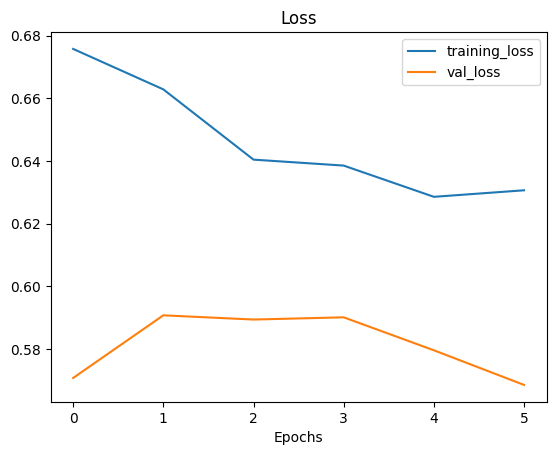

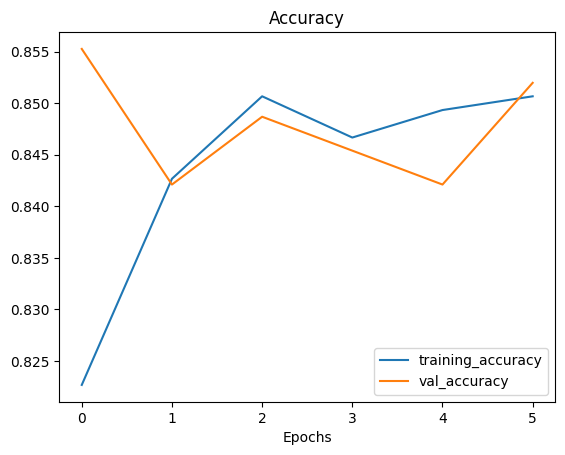

In [62]:
# Check out the loss curves of our fine-tuned model
plot_loss_curves(history_fine_10_percent_data_aug)

### Compare training histories

In [63]:
def compare_historys(original_history , new_history , initial_epochs=5):
  """
    Compares two TensorFlow History objects .
  """

  # Get original history measurements
  acc = original_history.history["accuracy"]
  loss = original_history.history["loss"]

  val_acc = original_history.history["val_accuracy"]
  val_loss = original_history.history["val_loss"]

  # Combine original history metrics with new_history metrics
  total_acc = acc + new_history.history["accuracy"]
  total_loss = loss + new_history.history["loss"]

  total_val_acc = val_acc + new_history.history["val_accuracy"]
  total_val_loss = val_loss + new_history.history["val_loss"]

  # Make plots 
  
  #Plot for accuracy
  
  plt.figure(figsize=(8,8))
  plt.subplot(2,1,1)
  plt.plot(total_acc , label="Training Accuracy")
  plt.plot(total_val_acc , label="Val Accuracy")
  plt.plot([initial_epochs-1, initial_epochs-1] , plt.ylim() , label="Start Fine Tuning")
  plt.legend(loc="lower right")
  plt.title("Training and Validation Accuracy")
  
  # Plot for loss
  plt.figure(figsize=(8,8))
  plt.subplot(2,1,2)
  plt.plot(total_loss, label="Training Loss")
  plt.plot(total_val_loss, label="Val Loss")
  plt.plot([initial_epochs-1 , initial_epochs-1] , plt.ylim() , label="Start Fine Tuning")
  plt.legend(loc="upper right")
  plt.title("Training and Validation Loss")  
  

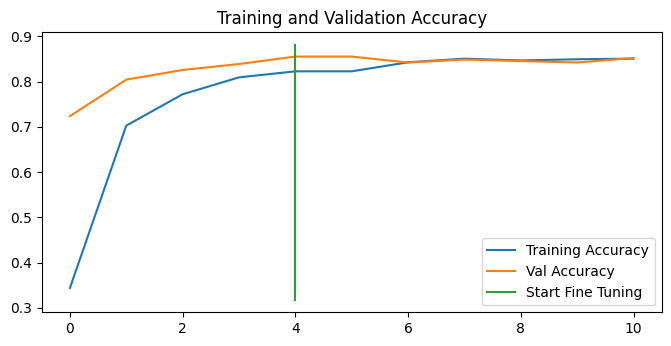

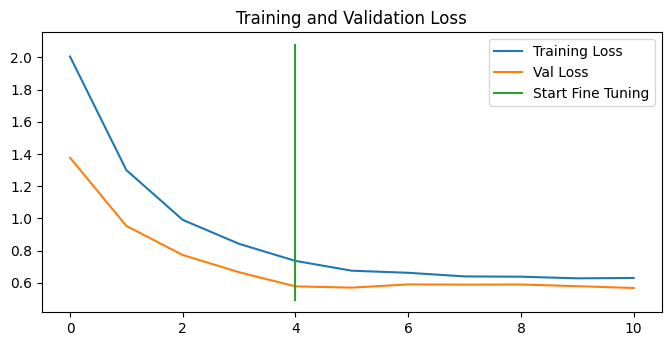

In [64]:
compare_historys(history_10_percent_data_aug,
                 history_fine_10_percent_data_aug,
                 initial_epochs=5)

## Model 4 : Fine-tuning and existing model on all of the data

In [65]:
# Download and unzip 10 classes of Food01 data with all images 
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
unzip_data("10_food_classes_all_data.zip")

--2026-03-07 13:46:21--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.253.118.207, 74.125.24.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  22.5MB/s    in 24s     

2026-03-07 13:46:45 (21.0 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
# Setup training and test dir
train_dir_all_data = "10_food_classes_all_data/train"
test_dir_all_data = "10_food_classes_all_data/test"

In [67]:
# How many images are we working with 
walk_through_dir("10_food_classes_all_data")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/train'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.

In [68]:
# Setup data inputs 
import tensorflow as tf

IMG_SIZE = (244 , 244)
train_data_10_classes_full = tf.keras.preprocessing.image_dataset_from_directory(train_dir_all_data,
                                                                                 label_mode="categorical",
                                                                                 image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [69]:
# Evaluate model 2 (this is the fine-tuned on 10 percent of data version)
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8541 - loss: 0.5695


[0.5630335807800293, 0.8543999791145325]

In [70]:
results_fine_tune_10_percent

[0.5630337595939636, 0.8543999791145325]

In [71]:
# Load weights from checkpoint , that way we can fine-tune from the same stage the 10 percent data model was fine-tuned from 
model_2.load_weights(checkpoint_path)

In [72]:
# Let's evaluate model_2 now 
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.8499 - loss: 0.6078


[0.6006181836128235, 0.8500000238418579]

In [73]:
# Check to see if our model_2 has been reverted back to feature extraction results
results_10_percent_data_aug

[0.6006181240081787, 0.8500000238418579]

Reminder :

1. Trained a feature extraction transfer learning for 5 epochs on 10% of the data with data augumentation (model_2) and we saved the model's weights using `ModelCheckpoint` callback .
2. Fine-tuned the same model on the same 10% of the data for a further 5 epochs with the top 10 layers of the base model unfrozen (model_3)
3. Saved the results and training logs each time .
4. Reloaded the model from step 1 to do the same steps as step 2 except this time we're going to use all the data (model_4) .

In [ ]:
model_2.layers[2].trainable = True

In [75]:
# Check which layers are tunnable in the whole model 
for layer_number , layer in enumerate(model_2.layers):
    print(layer_number , layers.name , layer.trainable)

0 top_activation True
1 top_activation True
2 top_activation True
3 top_activation True
4 top_activation True


In [76]:
# Let's drill into our base_model (efficientnetb0) and see what layers are trainable
for layer_number ,layer in enumerate(model_2.layers[2].layers):
    print(layer_number , layer.name , layer.trainable)

0 input_layer_2 True
1 rescaling_2 True
2 normalization_1 True
3 rescaling_3 True
4 stem_conv_pad True
5 stem_conv True
6 stem_bn True
7 stem_activation True
8 block1a_dwconv True
9 block1a_bn True
10 block1a_activation True
11 block1a_se_squeeze True
12 block1a_se_reshape True
13 block1a_se_reduce True
14 block1a_se_expand True
15 block1a_se_excite True
16 block1a_project_conv True
17 block1a_project_bn True
18 block2a_expand_conv True
19 block2a_expand_bn True
20 block2a_expand_activation True
21 block2a_dwconv_pad True
22 block2a_dwconv True
23 block2a_bn True
24 block2a_activation True
25 block2a_se_squeeze True
26 block2a_se_reshape True
27 block2a_se_reduce True
28 block2a_se_expand True
29 block2a_se_excite True
30 block2a_project_conv True
31 block2a_project_bn True
32 block2b_expand_conv True
33 block2b_expand_bn True
34 block2b_expand_activation True
35 block2b_dwconv True
36 block2b_bn True
37 block2b_activation True
38 block2b_se_squeeze True
39 block2b_se_reshape True
40 b

In [77]:
# Compile 
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                metrics=["accuracy"])

In [78]:
# Continue to train and fine-tune the model to our data (100% of training data)
fine_tune_epochs = initial_epochs + 5 

history_fine_10_class_full = model_2.fit(train_data_10_classes_full,
                                           epochs=fine_tune_epochs,
                                           validation_data=test_data,
                                           validation_steps=int(0.25 * len(test_data)),
                                           initial_epoch=history_10_percent_data_aug.epoch[-1],
                                           callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                                                  experiment_name="full_10_classes_fine_tune")])

Saving TensorBoard log files to: transfer_learning/full_10_classes_fine_tune/20260307-134712
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 137s 419ms/step - accuracy: 0.6540 - loss: 1.1419 - val_accuracy: 0.8980 - val_loss: 0.3183
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 95s 405ms/step - accuracy: 0.8389 - loss: 0.5309 - val_accuracy: 0.9112 - val_loss: 0.2683
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 407ms/step - accuracy: 0.8794 - loss: 0.3824 - val_accuracy: 0.9243 - val_loss: 0.2420
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 95s 406ms/step - accuracy: 0.8999 - loss: 0.3159 - val_accuracy: 0.9243 - val_loss: 0.2387
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 407ms/step - accuracy: 0.9230 - loss: 0.2548 - val_accuracy: 0.9178 - val_loss: 0.2433
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 408ms/step - accuracy: 0.9310 - loss: 0.2167 - val_accuracy: 0.9260 - val_loss: 0.2229


In [79]:
# Let's evaluate on all of the test data
results_fine_tune_full_data = model_2.evaluate(test_data)
results_fine_tune_full_data

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9249 - loss: 0.2302


[0.23548801243305206, 0.926800012588501]

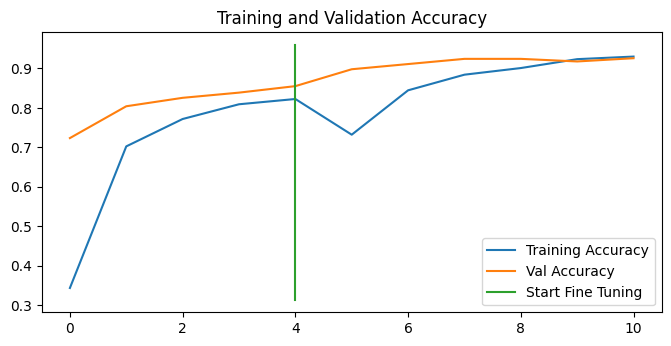

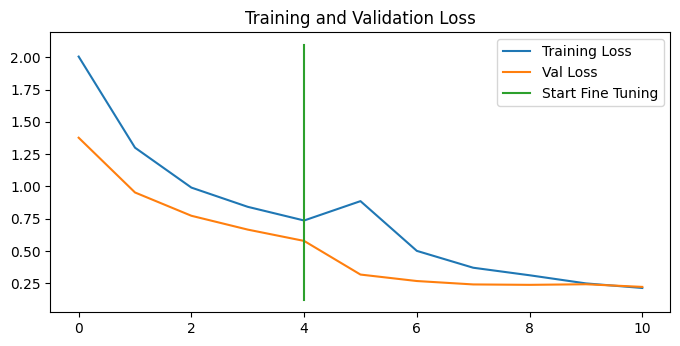

In [82]:
# How did fine-tuning go with more data 
compare_historys(original_history=history_10_percent_data_aug,
                new_history=history_fine_10_class_full,
                initial_epochs=5)